In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Column Name	Symbol / Code	Explanation
- job_title	Simplified Roles	Core job roles mapped to predefined categories (e.g., Accountant, Technician)
- job_date	Dates (Gregorian)	Date the job was posted
- comp_name	AS-IS	The company name remains as originally provided in the dataset
- comp_type	1, 0	1 - Private, 0 - Semi-Governmental
- comp_size	MA, MB, MC, etc.	Indicates the company size: MA - Medium A, SB - Small B, etc.
- eco_activity	Various Sectors	Generalized industry sector such as Trade and Retail, Healthcare
- region	Names (e.g., Eastern)	Translated and normalized Saudi regions (e.g., Eastern Province)
- city	Translated Names	Translated and normalized city names (e.g., AD DAMMAM, RIYADH)
- contract	1, 0	1 - Full-time, 0 - Remote
- benefits	1, 0	1 - Benefits offered, 0 - No benefits
- positions	Numbers (e.g., 10)	Number of positions available for the job
- exper	Numeric values	Years of experience required, converted to integers (e.g., 0, 2)
- gender	0, 1, 2	0 - Male, 1 - Female, 2 - Both
- Salary	Numeric values	Represents the salary in SAR

In [ ]:
df = pd.read_csv('data/processed_dataset.csv')
df.head()

,job_title,job_date,comp_name,comp_type,comp_size,eco_activity,region,city,benefits,contract,positions,exper,gender,Salary
0,Secretary,2022-10-01,مؤسسة دمك للمقاولات العامة,1,SB,Construction and Real Estate,Eastern,BUQAYQ,0,1,1,0,1,4000.0
1,Salesperson,2022-10-03,شركة محمد سراج عطار وأخويه,1,SB,Trade and Retail,Makkah,JEDDAH,1,1,3,0,0,4000.0
2,Receptionist,2022-10-08,مركز شار لطب الاسنان,1,MA,Trade and Retail,Makkah,JEDDAH,1,1,2,4,1,4000.0
3,Accountant,2022-10-12,شركة اسواق بساتين القصيم,1,MB,Trade and Retail,Riyadh,AR RIYADH,1,1,10,0,2,4000.0
4,Secretary,2022-10-13,شركة السبائك الذهبية للمعادن الثمينة,1,SA,Trade and Retail,Makkah,JEDDAH,1,1,1,2,1,5000.0


In [21]:
print("shape of the dataset:", df.shape)
print("number of missing values in each column:")
print(df.isnull().sum())

shape of the dataset: (1470, 14)
number of missing values in each column:
job_title       0
job_date        0
comp_name       0
comp_type       0
comp_size       0
eco_activity    0
region          0
city            0
benefits        0
contract        0
positions       0
exper           0
gender          0
Salary          0
dtype: int64


In [22]:
print("dataset information:")
df.info()

dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   job_title     1470 non-null   str    
 1   job_date      1470 non-null   str    
 2   comp_name     1470 non-null   str    
 3   comp_type     1470 non-null   int64  
 4   comp_size     1470 non-null   str    
 5   eco_activity  1470 non-null   str    
 6   region        1470 non-null   str    
 7   city          1470 non-null   str    
 8   benefits      1470 non-null   int64  
 9   contract      1470 non-null   int64  
 10  positions     1470 non-null   int64  
 11  exper         1470 non-null   int64  
 12  gender        1470 non-null   int64  
 13  Salary        1470 non-null   float64
dtypes: float64(1), int64(6), str(7)
memory usage: 337.2 KB


In [24]:
most_job_title = df['job_title'].value_counts().head(10)
most_job_title

job_title
Analyst                     235
Salesperson                 195
Accountant                  128
Manager                     127
Technician                  112
Engineer                     87
Switchboard Operator         76
Receptionist                 62
Secretary                    47
Administrative Assistant     45
Name: count, dtype: int64

In [31]:
avgSalary_byRegion = df.groupby('region')['Salary'].mean()
avgSalary_byRegion

region
Al Baha             5902.304348
Al Jouf             4800.000000
Asir                4502.404762
Eastern             5271.187215
Hail                6455.444444
Jazan               4020.000000
Madinah             4971.372093
Makkah              5246.091892
Najran              5750.000000
Northern Borders    8300.000000
Qassim              4631.250000
Riyadh              5360.143087
Tabuk               6345.454545
Name: Salary, dtype: float64

In [33]:
df['comp_type_label'] = df['comp_type'].map({0: 'Semi-Gov', 1: 'Private'})
avgSalary_byType = df.groupby('comp_type_label')['Salary'].mean()
avgSalary_byType

comp_type_label
Private     5283.518089
Semi-Gov    8556.400000
Name: Salary, dtype: float64

In [34]:
experVsSalary = df.groupby('exper')['Salary'].mean()
experVsSalary

exper
0      4712.236495
2      5277.967890
4      6621.026144
7     10043.333333
10    13988.800000
12    10833.333333
Name: Salary, dtype: float64

In [40]:
avgSalary_byJob = df.groupby('job_title')['Salary'].mean().sort_values(ascending=False).head(10)
avgSalary_byJob

job_title
Pilot            35000.000000
CEO               9312.500000
Developer         8343.750000
Doctor            8000.000000
Engineer          7429.114943
HR Specialist     6586.607143
Pharmacist        6541.666667
Electrician       6513.636364
Dentist           6250.000000
Artist            6012.333333
Name: Salary, dtype: float64

In [53]:
city_salary = df.groupby('city')['Salary'].agg(['mean','count']).sort_values('mean', ascending=False)
city_salary[city_salary['count'] > 10]

,mean,count
city,,
HAFAR AL,8357.142857,14
YANBU AS,7375.000000,12
ABA ASLAB,6414.509804,51
HAIL,6011.647059,17
AL BAHA,5646.083333,24
JEDDAH,5376.693878,245
AR RIYADH,5302.506692,523
AD DAMMAM,5201.102564,78
MAKKAH AL MUKARRAMAH,5175.000000,72


In [56]:
df['benefits_map']= df['benefits'].map({0: 'no' , 1:'yes'})
benefits_salary = df.groupby('benefits_map')['Salary'].mean()
benefits_salary

benefits_map
no     5301.356481
yes    5276.079487
Name: Salary, dtype: float64

In [63]:
most_eco_activity = df['eco_activity'].value_counts().sort_values(ascending=False).head(10)
most_eco_activity

eco_activity
Tertiary and Services                  307
Trade and Retail                       265
Construction and Real Estate           162
Food Services                          141
Technical Services                     107
Consulting and Profissonal Services     97
Industrial Manufacturing                94
Healthcare and Pharmaceuticals          93
Technology and Communications           54
Logistics and Transportation            53
Name: count, dtype: int64

In [78]:
df['job_date'] = pd.to_datetime(df['job_date'])
df['month'] = df['job_date'].dt.month
jobInMonth = df['month'].value_counts()
jobInMonth

month
11    487
12    478
1     418
10     87
Name: count, dtype: int64

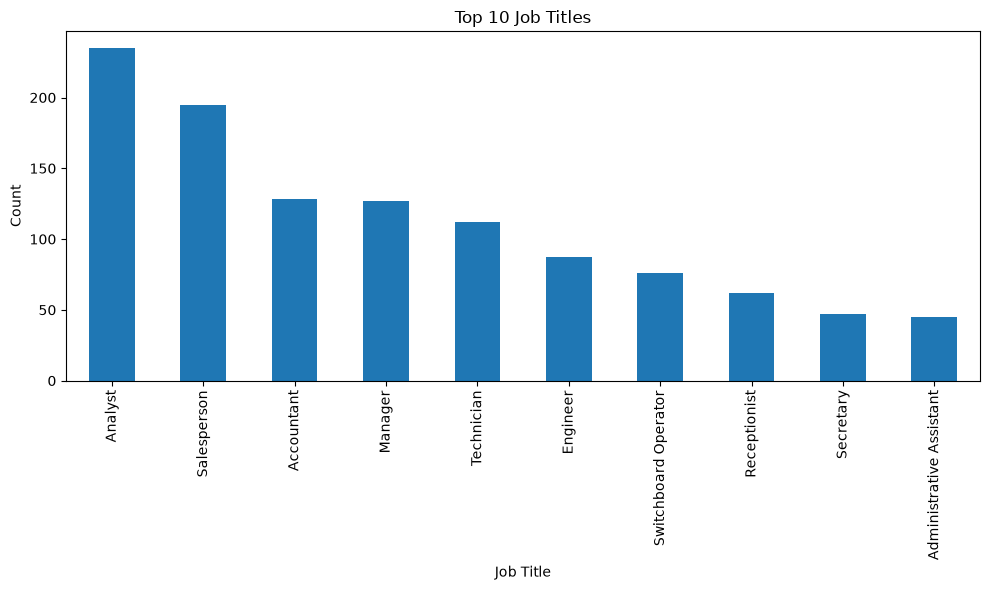

In [81]:
plt.figure(figsize=(10, 6))
most_job_title.plot(kind='bar')
plt.title('Top 10 Job Titles')
plt.xlabel('Job Title')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

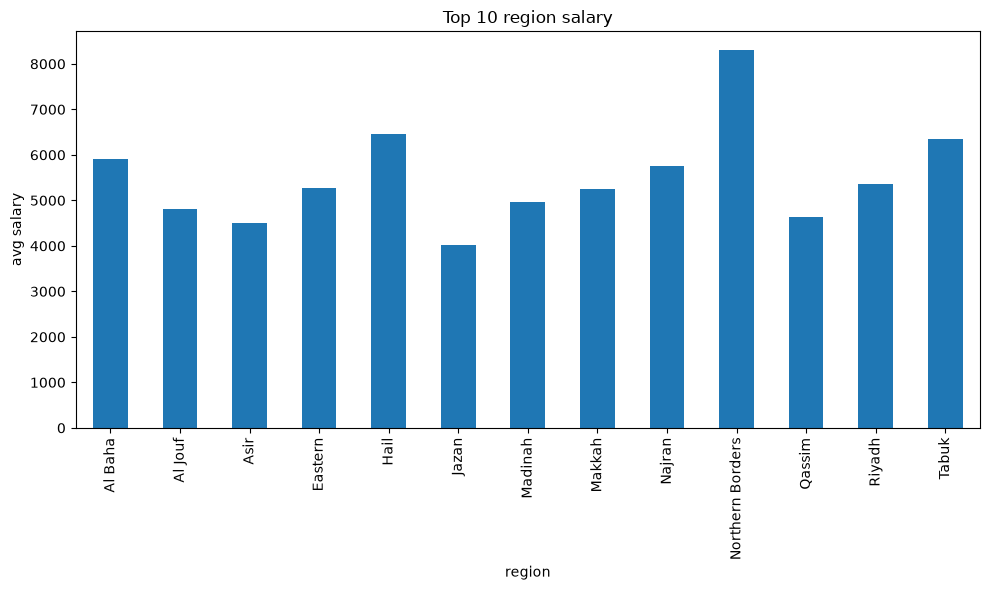

In [83]:
plt.figure(figsize=(10, 6))
avgSalary_byRegion.plot(kind='bar')
plt.title('Top 10 region salary')
plt.xlabel('region')
plt.ylabel('avg salary')
plt.tight_layout()
plt.show()

In [84]:
# go to power bi
df.to_csv('saudi_jobs_cleaned.csv', index=False)

In [85]:
df.head()

,job_title,job_date,comp_name,comp_type,comp_size,eco_activity,region,city,benefits,contract,positions,exper,gender,Salary,comp_type_label,benefits_map,month
0,Secretary,2022-10-01,مؤسسة دمك للمقاولات العامة,1,SB,Construction and Real Estate,Eastern,BUQAYQ,0,1,1,0,1,4000.0,Private,no,10
1,Salesperson,2022-10-03,شركة محمد سراج عطار وأخويه,1,SB,Trade and Retail,Makkah,JEDDAH,1,1,3,0,0,4000.0,Private,yes,10
2,Receptionist,2022-10-08,مركز شار لطب الاسنان,1,MA,Trade and Retail,Makkah,JEDDAH,1,1,2,4,1,4000.0,Private,yes,10
3,Accountant,2022-10-12,شركة اسواق بساتين القصيم,1,MB,Trade and Retail,Riyadh,AR RIYADH,1,1,10,0,2,4000.0,Private,yes,10
4,Secretary,2022-10-13,شركة السبائك الذهبية للمعادن الثمينة,1,SA,Trade and Retail,Makkah,JEDDAH,1,1,1,2,1,5000.0,Private,yes,10


# LEVEL 3

In [121]:
# ML
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['comp_size_enc'] = le.fit_transform(df['comp_size'])
df['eco_activity_enc'] = le.fit_transform(df['eco_activity'])
df['region_enc'] = le.fit_transform(df['region'])
df['city_enc'] = le.fit_transform(df['city'])
df['job_title_enc'] = le.fit_transform(df['job_title'])

In [122]:
features = ['comp_type','comp_size_enc','eco_activity_enc','region_enc','city_enc','exper','job_title_enc']
x = df[features]
y = df['Salary']

In [123]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y , test_size=0.2 , random_state=42)

In [124]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score

model_1 = RandomForestRegressor(n_estimators=100, random_state=42)
model_1.fit(x_train,y_train)

model_2 = DecisionTreeRegressor(random_state=42)
model_2.fit(x_train,y_train)

model_3 = LinearRegression()
model_3.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[-2814.01, -161.8 , 0.78,..., 1.52, 647.97, -13.8 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['comp_type','comp_size_enc','eco_activity_enc',...,'city_enc','exper', 'job_title_enc']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8189
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,7


In [125]:
predictions_1 = model_1.predict(x_test)
mae_1 = mean_absolute_error(y_test, predictions_1)
print(f"model_1 - Average prediction error: {mae_1:,.0f} SAR")

predictions_2 = model_2.predict(x_test)
mae_2 = mean_absolute_error(y_test, predictions_2)
print(f"model_2 - Average prediction error: {mae_2:,.0f} SAR")

predictions_3 = model_3.predict(x_test)
mae_3 = mean_absolute_error(y_test, predictions_3)
print(f"model_3 - Average prediction error: {mae_3:,.0f} SAR")

model_1 - Average prediction error: 913 SAR
model_2 - Average prediction error: 1,066 SAR
model_3 - Average prediction error: 1,210 SAR


In [126]:
pd.Series(model_1.feature_importances_, index=features).sort_values(ascending=False)

exper               0.333017
job_title_enc       0.192290
comp_size_enc       0.172251
eco_activity_enc    0.130910
city_enc            0.119461
region_enc          0.047893
comp_type           0.004177
dtype: float64

# LEVEL 4

In [127]:
scores = cross_val_score(model_1, x, y, cv=5, scoring='neg_mean_absolute_error')
print(f"Cross Validation MAE: {(-scores.mean()):,.0f} SAR")

Cross Validation MAE: 1,134 SAR


In [128]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [50, 100, 150, 200, 250, 300]}

In [129]:
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid,cv=5,scoring='neg_mean_absolute_error')
grid_search.fit(x,y)
print(f"Best n_estimators: {grid_search.best_params_}")
print(f"Best MAE: {(-grid_search.best_score_):,.0f} SAR")

Best n_estimators: {'n_estimators': 100}
Best MAE: 1,134 SAR


In [130]:
from sklearn.metrics import r2_score

scores = r2_score(y_test,predictions_1)
print(f"r2_score: {scores:.4f}")

r2_score: 0.4268


# LEVEL 5

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error

features = ['region', 'eco_activity', 'city', 'comp_size', 'job_title', 'exper', 'comp_type']
x = df[features]
y = df['Salary']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

categorical_cols = ['region', 'eco_activity', 'city', 'comp_size', 'job_title']
numerical_cols = ['exper', 'comp_type']

preprocessor = ColumnTransformer([
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
    ('num', 'passthrough', numerical_cols)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])


pipeline.fit(x_train, y_train)

predictions = pipeline.predict(x_test)
print(f"Pipeline MAE: {mean_absolute_error(y_test, predictions):,.0f} SAR")

Pipeline MAE: 924 SAR


In [140]:
# try new job
new_job = pd.DataFrame([{
    'region': 'Riyadh',
    'eco_activity': 'Technology and Communications',
    'city': 'AR RIYADH',
    'comp_size': 'MA',
    'job_title': 'Analyst',
    'exper': 10,
    'comp_type': 1
}])

predicted_salary = pipeline.predict(new_job)
print(f"Predicted Salary: {predicted_salary[0]:,.0f} SAR")

Predicted Salary: 11,318 SAR


In [141]:
import pickle
with open('model.pkl', 'wb') as f:
    pickle.dump(pipeline, f)